# 04 – Hidden Markov Model (HMM)

---

### Vad gör vi i den här notebooken?

Hidden Markov Model (HMM) är vår första och enda **osupervised** modell – den identifierar marknadsregimer utan att använda våra bull/bear-etiketter under träning. Det gör den till en naturlig statistisk baseline att jämföra de supervisionerade ML-modellerna mot.

**Hur fungerar HMM?**  
HMM antar att marknaden vid varje tidpunkt befinner sig i ett **dolt tillstånd** (t.ex. bull eller bear) som vi inte kan observera direkt. Det vi observerar är dagliga avkastningar, volatilitet och trendposition. Modellen lär sig:
- Sannolikheten att vara i varje tillstånd
- Sannolikheten att byta tillstånd
- Hur observationerna ser ut i varje tillstånd

**Vi tränar två versioner:**
- **2-tillståndsmodell** – bull och bear, direkt jämförbar med våra etiketter
- **3-tillståndsmodell** – bull, neutral och bear, mer realistisk men komplexare

**Features:**
- `Return` – daglig avkastning (riktning)
- `Vol_20d` – rullande 20-dagarsvolatilitet (oro)
- `Price_MA200` – pris/MA200-ratio (trendposition)

**Input:**  `data/sp500_features.csv`, `data/bitcoin_features.csv`, `data/gold_features.csv`  
**Output:** `data/sp500_hmm.csv`, `data/bitcoin_hmm.csv`, `data/gold_hmm.csv`

## 1. Importera bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR    = '../data'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Läs in data

Vi läser in features-filerna från `03_feature_engineering.ipynb`.

In [5]:
assets = {}

files = {
    'SP500':   'sp500_features.csv',
    'Bitcoin': 'bitcoin_features.csv',
    'Gold':    'gold_features.csv',
}

for name, filename in files.items():
    path = os.path.join(DATA_DIR, filename)
    df   = pd.read_csv(path, index_col='Date', parse_dates=True)
    assets[name] = df
    bull = (df['Regime'] == 1).sum()
    bear = (df['Regime'] == 0).sum()
    print(f'✓ {name}: {len(df)} rader | Bull: {bull} ({bull/len(df)*100:.1f}%) | Bear: {bear} ({bear/len(df)*100:.1f}%)')

✓ SP500: 2764 rader | Bull: 2475 (89.5%) | Bear: 289 (10.5%)
✓ Bitcoin: 2665 rader | Bull: 2085 (78.2%) | Bear: 580 (21.8%)
✓ Gold: 2764 rader | Bull: 2489 (90.1%) | Bear: 275 (9.9%)


## 3. Förbered features för HMM

Vi väljer tre features som ger HMM information om:
- **Return** – marknadens riktning (positiv i bull, negativ i bear)
- **Vol_20d** – marknadens oro (hög i bear, låg i bull)
- **Price_MA200** – trendposition (>1.0 i bull, <1.0 i bear)

Features standardiseras med StandardScaler så att de har samma skala.

In [6]:
HMM_FEATURES = ['Return', 'Vol_20d', 'Price_MA200']

def prepare_hmm_data(df: pd.DataFrame) -> tuple:
    """Förbereder och standardiserar features för HMM."""
    data   = df[HMM_FEATURES].dropna()
    scaler = StandardScaler()
    X      = scaler.fit_transform(data)
    y      = df['Regime'].reindex(data.index).values
    return X, y, data.index, scaler

print(f'HMM features: {HMM_FEATURES}')
print('\nFeature-statistik per tillgång:')
for name, df in assets.items():
    print(f'\n{name}:')
    print(df[HMM_FEATURES].describe().round(4))

HMM features: ['Return', 'Vol_20d', 'Price_MA200']

Feature-statistik per tillgång:

SP500:
          Return    Vol_20d  Price_MA200
count  2764.0000  2764.0000    2764.0000
mean      0.0005     0.0094       1.0443
std       0.0113     0.0064       0.0629
min      -0.1198     0.0021       0.7368
25%      -0.0038     0.0057       1.0147
50%       0.0007     0.0078       1.0534
75%       0.0058     0.0115       1.0868
max       0.0952     0.0612       1.1710

Bitcoin:
          Return    Vol_20d  Price_MA200
count  2665.0000  2665.0000    2665.0000
mean      0.0024     0.0310       1.1919
std       0.0379     0.0156       0.4153
min      -0.3717     0.0049       0.5077
25%      -0.0138     0.0197       0.9090
50%       0.0013     0.0281       1.1288
75%       0.0183     0.0381       1.3491
max       0.2525     0.1091       3.9275

Gold:
          Return    Vol_20d  Price_MA200
count  2764.0000  2764.0000    2764.0000
mean      0.0005     0.0091       1.0424
std       0.0097     0.0034   

## 4. Träna HMM – 2 tillstånd

Vi tränar en Gaussian HMM med 2 dolda tillstånd (bull och bear) för varje tillgång.

**Mappning av tillstånd:**  
HMM numrerar tillstånden slumpmässigt (0 och 1). Vi mappar automatiskt:
- Tillståndet med **högst genomsnittlig avkastning** → Bull (1)
- Tillståndet med **lägst genomsnittlig avkastning** → Bear (0)

In [18]:
def train_hmm(X: np.ndarray, n_states: int, random_state: int = 42) -> GaussianHMM:
    """Tränar en Gaussian HMM med n_states tillstånd."""
    model = GaussianHMM(
        n_components=n_states,
        covariance_type='full',
        n_iter=1000,
        random_state=random_state,
    )
    model.fit(X)
    return model

def smooth_states(states: np.ndarray, min_days: int = 10) -> np.ndarray:
    """Filtrerar bort korta regimskiften under min_days dagar."""
    smoothed = states.copy()
    i = 0
    while i < len(smoothed):
        current = smoothed[i]
        j = i
        while j < len(smoothed) and smoothed[j] == current:
            j += 1
        duration = j - i
        if duration < min_days and i > 0:
            smoothed[i:j] = smoothed[i - 1]
        i = j
    return smoothed

def map_states_to_regimes(states: np.ndarray, X_raw: np.ndarray,
                           n_states: int, smooth: bool = True) -> np.ndarray:
    mean_returns = {s: X_raw[states == s, 0].mean() for s in range(n_states)}
    sorted_states = sorted(mean_returns, key=mean_returns.get)

    if n_states == 2:
        mapping = {sorted_states[0]: 0, sorted_states[1]: 1}
    else:
        mapping = {
            sorted_states[0]: 0,
            sorted_states[1]: 1,
            sorted_states[2]: 1,
        }

    mapped = np.array([mapping[s] for s in states])
    if smooth:
        mapped = smooth_states(mapped, min_days=30)
    return mapped

print('✓ Funktioner definierade med smoothing (min 30 dagar)')

✓ Funktioner definierade med smoothing (min 30 dagar)


In [19]:
# Träna 2-tillståndsmodell för alla tillgångar
results_2state = {}

print('══ HMM – 2 tillstånd ══════════════════════════════════')

for name, df in assets.items():
    X, y_true, idx, scaler = prepare_hmm_data(df)
    X_raw = df[HMM_FEATURES].dropna().values

    # Träna modell
    model  = train_hmm(X, n_states=2)
    states = model.predict(X)

    # Mappa tillstånd till bull/bear
    y_pred = map_states_to_regimes(states, X_raw, n_states=2)

    # Utvärdera
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')

    results_2state[name] = {
        'model':  model,
        'states': states,
        'y_pred': y_pred,
        'y_true': y_true,
        'index':  idx,
        'acc':    acc,
        'f1':     f1,
        'X_raw':  X_raw,
    }

    print(f'\n── {name} ──────────────────────────────')
    print(f'  Accuracy : {acc:.3f}')
    print(f'  F1-score : {f1:.3f}')
    print(classification_report(y_true, y_pred, target_names=['Bear', 'Bull']))

══ HMM – 2 tillstånd ══════════════════════════════════

── SP500 ──────────────────────────────
  Accuracy : 0.790
  F1-score : 0.827
              precision    recall  f1-score   support

        Bear       0.31      0.85      0.46       289
        Bull       0.98      0.78      0.87      2475

    accuracy                           0.79      2764
   macro avg       0.65      0.82      0.66      2764
weighted avg       0.91      0.79      0.83      2764


── Bitcoin ──────────────────────────────
  Accuracy : 0.318
  F1-score : 0.350
              precision    recall  f1-score   support

        Bear       0.16      0.50      0.24       580
        Bull       0.66      0.27      0.38      2085

    accuracy                           0.32      2665
   macro avg       0.41      0.39      0.31      2665
weighted avg       0.55      0.32      0.35      2665


── Gold ──────────────────────────────
  Accuracy : 0.474
  F1-score : 0.560
              precision    recall  f1-score   suppor

## 5. Träna HMM – 3 tillstånd

Vi tränar samma modell men med 3 tillstånd: bull, neutral och bear.

**Mappning för 3 tillstånd:**  
- Högst avkastning → Bull (1)
- Mitten → Neutral (mappas till Bull för jämförbarhet)
- Lägst avkastning → Bear (0)

In [20]:
results_3state = {}

print('══ HMM – 3 tillstånd ══════════════════════════════════')

for name, df in assets.items():
    X, y_true, idx, scaler = prepare_hmm_data(df)
    X_raw = df[HMM_FEATURES].dropna().values

    model  = train_hmm(X, n_states=3)
    states = model.predict(X)

    # Visa statistik per tillstånd
    print(f'\n── {name} – Tillståndsstatistik ────────────────')
    for s in range(3):
        mask = states == s
        mean_ret = X_raw[mask, 0].mean() * 100
        mean_vol = X_raw[mask, 1].mean() * 100
        print(f'  Tillstånd {s}: {mask.sum()} dagar | '
              f'Avg avkastning: {mean_ret:+.3f}% | '
              f'Avg volatilitet: {mean_vol:.4f}')

    y_pred = map_states_to_regimes(states, X_raw, n_states=3)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')

    results_3state[name] = {
        'model':  model,
        'states': states,
        'y_pred': y_pred,
        'y_true': y_true,
        'index':  idx,
        'acc':    acc,
        'f1':     f1,
        'X_raw':  X_raw,
    }

    print(f'  Accuracy : {acc:.3f}')
    print(f'  F1-score : {f1:.3f}')
    print(classification_report(y_true, y_pred, target_names=['Bear', 'Bull']))

══ HMM – 3 tillstånd ══════════════════════════════════

── SP500 – Tillståndsstatistik ────────────────
  Tillstånd 0: 927 dagar | Avg avkastning: +0.044% | Avg volatilitet: 0.5634
  Tillstånd 1: 1096 dagar | Avg avkastning: +0.105% | Avg volatilitet: 0.7982
  Tillstånd 2: 741 dagar | Avg avkastning: -0.025% | Avg volatilitet: 1.6305
  Accuracy : 0.829
  F1-score : 0.856
              precision    recall  f1-score   support

        Bear       0.36      0.83      0.51       289
        Bull       0.98      0.83      0.90      2475

    accuracy                           0.83      2764
   macro avg       0.67      0.83      0.70      2764
weighted avg       0.91      0.83      0.86      2764


── Bitcoin – Tillståndsstatistik ────────────────
  Tillstånd 0: 1057 dagar | Avg avkastning: +0.238% | Avg volatilitet: 2.1094
  Tillstånd 1: 638 dagar | Avg avkastning: +0.712% | Avg volatilitet: 4.8450
  Tillstånd 2: 970 dagar | Avg avkastning: -0.068% | Avg volatilitet: 3.0373
  Accuracy : 0.

## 6. Visualisera regimer – 2/3 tillstånd

Vi plottar stängningspriset med HMM:s identifierade regimer (grön = bull, röd = bear) och jämför med vår ground truth.

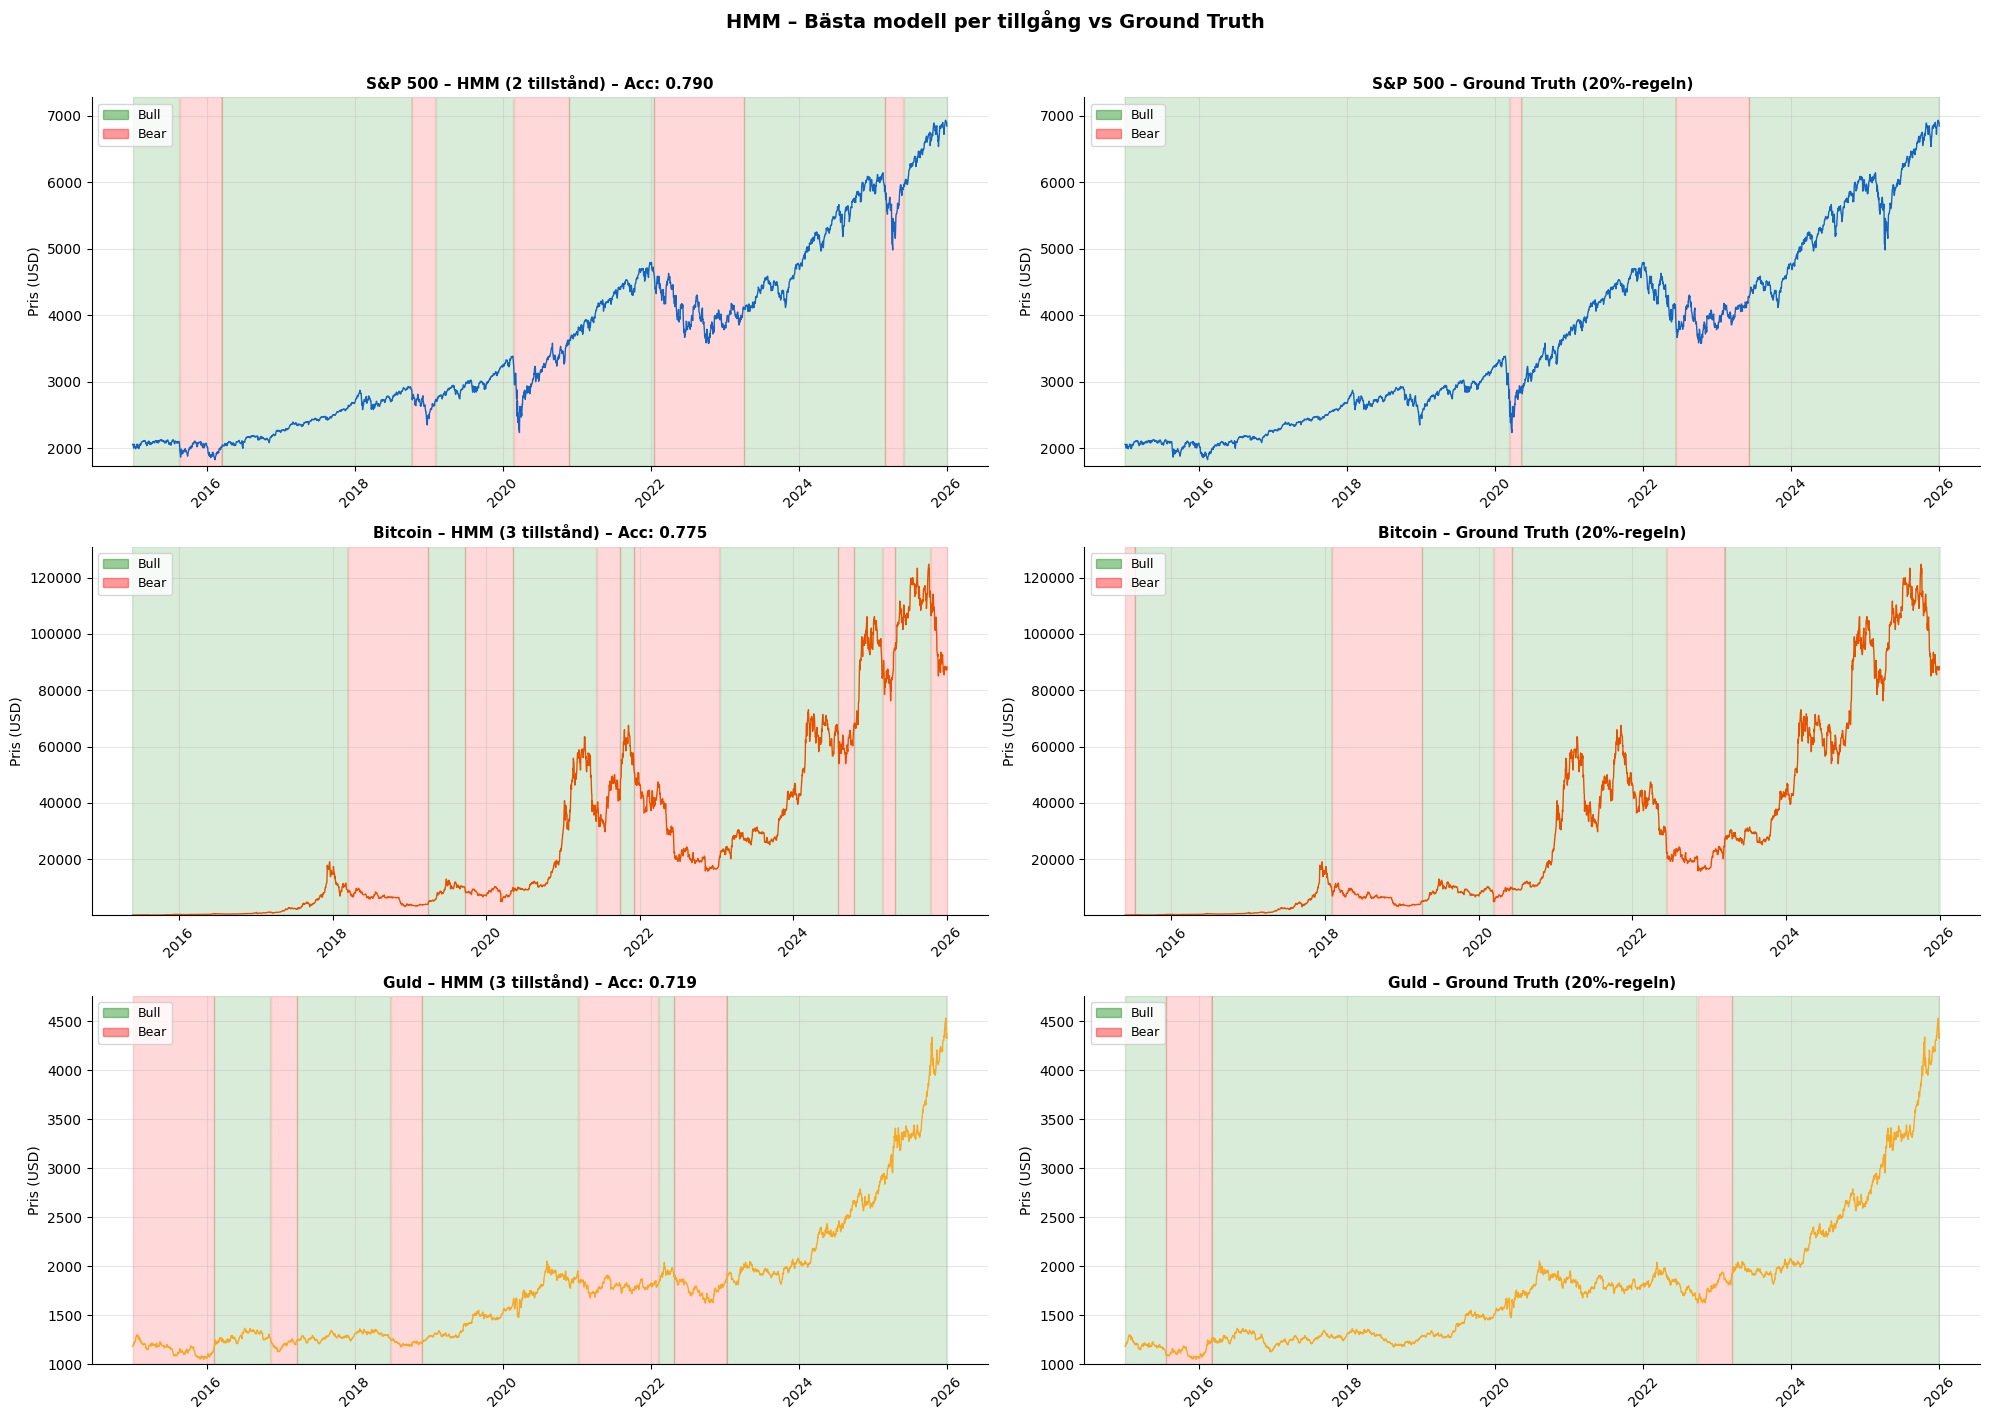

✓ Graf sparad: results/04_hmm_best.png


In [22]:
fig, axes = plt.subplots(3, 2, figsize=(20, 14))

for row, (name, df) in enumerate(assets.items()):
    r2  = results_2state[name]
    r3  = results_3state[name]
    close = df['Close'].reindex(r2['index'])

    # Vänster: 2-tillstånd för SP500, 3-tillstånd för Bitcoin och Guld
    if name == 'SP500':
        pred  = r2['y_pred']
        title = f'HMM (2 tillstånd) – Acc: {r2["acc"]:.3f}'
    else:
        pred  = r3['y_pred']
        title = f'HMM (3 tillstånd) – Acc: {r3["acc"]:.3f}'

    # Höger: Ground Truth alltid
    for col, (p, t) in enumerate([
        (pred,          title),
        (r2['y_true'],  'Ground Truth (20%-regeln)'),
    ]):
        ax = axes[row, col]
        regime_series = pd.Series(p, index=r2['index'])

        ax.fill_between(close.index, close.min()*0.95, close.max()*1.05,
                        where=(regime_series == 1), alpha=0.15, color='green')
        ax.fill_between(close.index, close.min()*0.95, close.max()*1.05,
                        where=(regime_series == 0), alpha=0.15, color='red')
        ax.plot(close.index, close, color=colors[name], linewidth=1)
        ax.set_title(f'{labels_map[name]} – {t}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Pris (USD)')
        ax.set_ylim(close.min()*0.95, close.max()*1.05)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.tick_params(axis='x', rotation=45)

        bull_patch = mpatches.Patch(color='green', alpha=0.4, label='Bull')
        bear_patch = mpatches.Patch(color='red',   alpha=0.4, label='Bear')
        ax.legend(handles=[bull_patch, bear_patch], fontsize=9, loc='upper left')

plt.suptitle('HMM – Bästa modell per tillgång vs Ground Truth',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '04_hmm_best.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/04_hmm_best.png')

### Visualisering – HMM bästa modell per tillgång vs Ground Truth

Vänster kolumn visar HMM:s identifierade regimer, höger kolumn visar ground truth (20%-regeln).
Vi använder den bäst presterande modellen per tillgång:
- **S&P 500** – 2-tillståndsmodell (Acc: 0.790)
- **Bitcoin** – 3-tillståndsmodell (Acc: 0.775)
- **Guld** – 3-tillståndsmodell (Acc: 0.719)

**Vad vi ser:**
- S&P 500 fångar COVID 2020 och räntehöjningarna 2022 korrekt
- Bitcoin fångar kryptovintern 2018 och FTX-kraschen 2022, men missar delar av 2024-2025 bull market på grund av extrem volatilitet under uppgången
- Guld identifierar de två bear-perioderna (2015–2016 och 2022) relativt väl

**Viktigt fynd:** S&P 500 fungerar bra med 2 tillstånd medan Bitcoin och Guld kräver 3 tillstånd – det neutrala tillståndet fångar ackumulerings- och konsolideringsfaser som annars klassificeras fel.

## 8. Övergångsmatriser

Övergångsmatrisen visar sannolikheten att byta från ett tillstånd till ett annat. Höga diagonalvärden indikerar att tillstånden är persistenta – marknaden tenderar att stanna i samma regim.

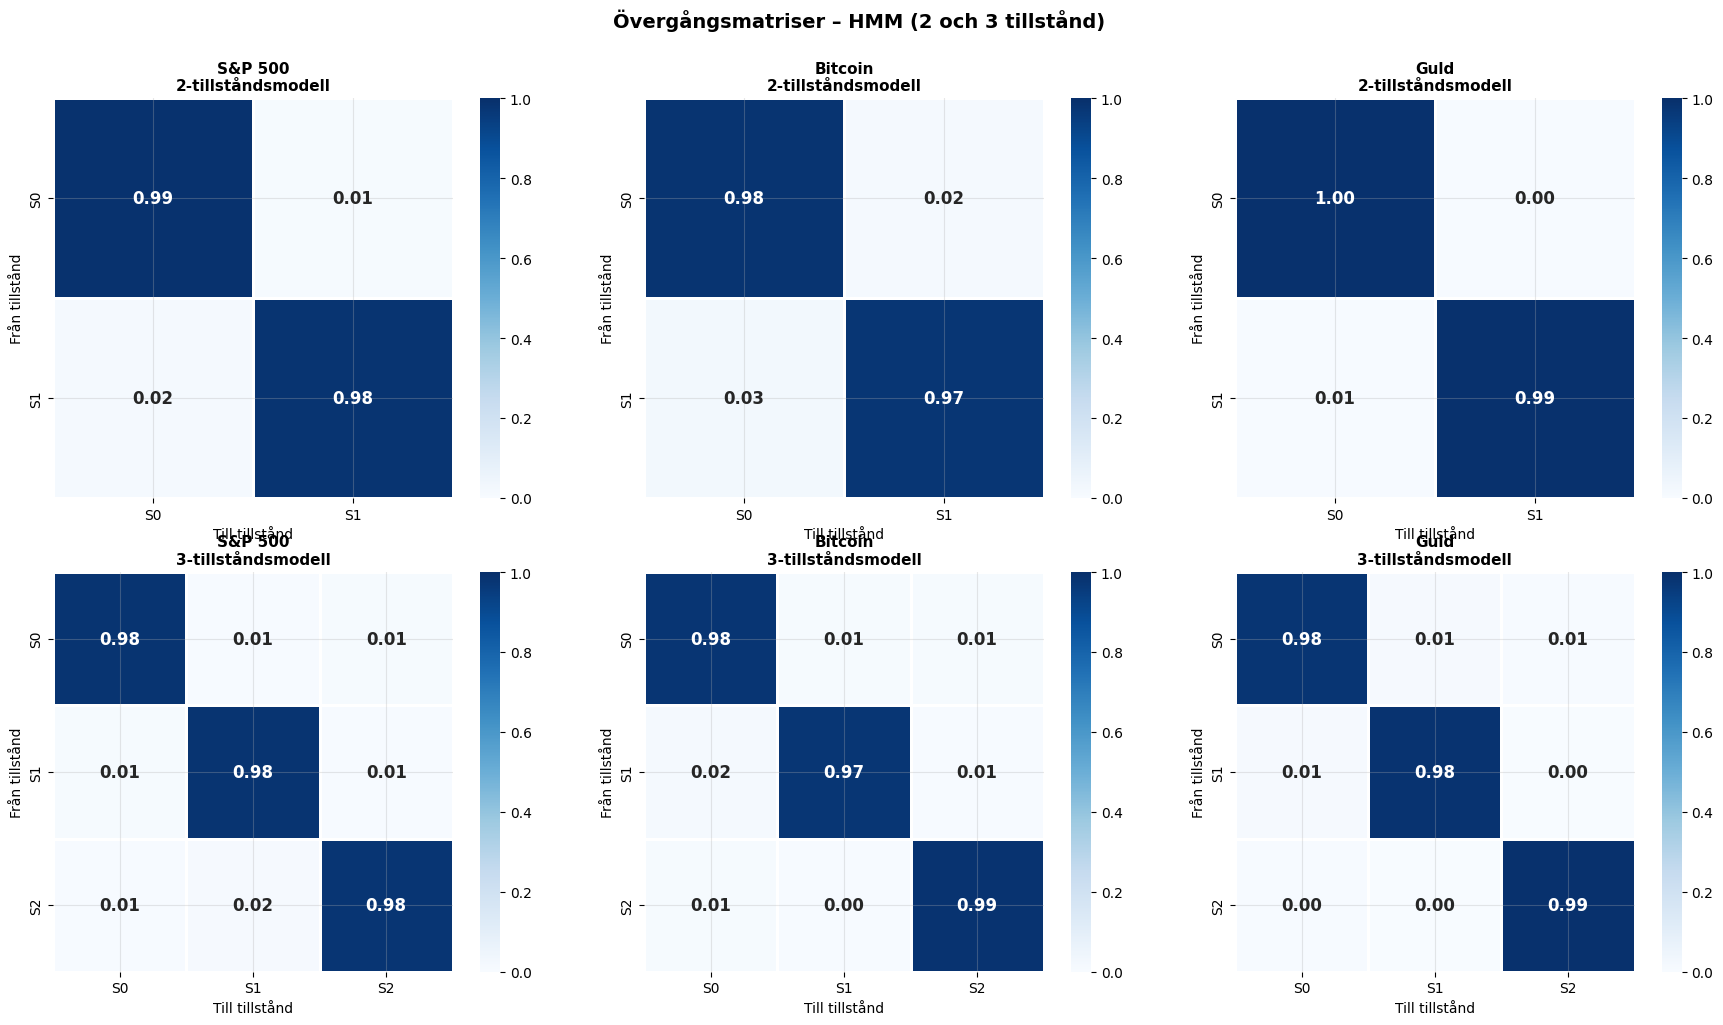

✓ Graf sparad: results/04_hmm_transitions.png


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, df) in enumerate(assets.items()):
    for row, (n_states, results) in enumerate([(2, results_2state), (3, results_3state)]):
        ax    = axes[row, col]
        model = results[name]['model']
        trans = pd.DataFrame(
            model.transmat_,
            columns=[f'S{i}' for i in range(n_states)],
            index=[f'S{i}' for i in range(n_states)]
        )

        sns.heatmap(trans, ax=ax, annot=True, fmt='.2f',
                    cmap='Blues', vmin=0, vmax=1,
                    linewidths=1, square=True,
                    annot_kws={'size': 12, 'weight': 'bold'})
        ax.set_title(f'{labels_map[name]}\n{n_states}-tillståndsmodell',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Till tillstånd')
        ax.set_ylabel('Från tillstånd')

plt.suptitle('Övergångsmatriser – HMM (2 och 3 tillstånd)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '04_hmm_transitions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/04_hmm_transitions.png')

### Visualisering – Övergångsmatriser

Övergångsmatrisen visar sannolikheten att byta från ett tillstånd till ett annat dag för dag.

**Vad vi ser:**
- Alla diagonalvärden är 0.97–0.99 – marknaden stannar nästan alltid i samma regim nästa dag
- Off-diagonal värden (0.01–0.03) representerar sannolikheten för ett regimskifte
- Detta bekräftar att bull och bear markets är **persistenta strukturella tillstånd**, inte slumpmässiga dagliga fluktuationer
- Resultatet stämmer väl med den ekonomiska teorin om marknadsregimer

## 9. Jämförelse 2 vs 3 tillstånd

Här jämför vi prestandan för 2- och 3-tillståndsmodellerna mot ground truth.

In [13]:
print('══ Jämförelse – HMM 2 vs 3 tillstånd ═════════════════')
print(f'{"Tillgång":<12} {"2-state Acc":>14} {"2-state F1":>12} {"3-state Acc":>14} {"3-state F1":>12}')
print('-' * 68)

comparison = []
for name in assets:
    r2 = results_2state[name]
    r3 = results_3state[name]
    print(f'{name:<12} {r2["acc"]:>14.3f} {r2["f1"]:>12.3f} {r3["acc"]:>14.3f} {r3["f1"]:>12.3f}')
    comparison.append({
        'Tillgång':     name,
        '2-state Acc':  round(r2['acc'], 3),
        '2-state F1':   round(r2['f1'],  3),
        '3-state Acc':  round(r3['acc'], 3),
        '3-state F1':   round(r3['f1'],  3),
    })

comp_df = pd.DataFrame(comparison)
display(comp_df)

══ Jämförelse – HMM 2 vs 3 tillstånd ═════════════════
Tillgång        2-state Acc   2-state F1    3-state Acc   3-state F1
--------------------------------------------------------------------
SP500                 0.750        0.797          0.788        0.824
Bitcoin               0.395        0.438          0.761        0.779
Gold                  0.461        0.549          0.716        0.772


,Tillgång,2-state Acc,2-state F1,3-state Acc,3-state F1
0,SP500,0.750,0.797,0.788,0.824
1,Bitcoin,0.395,0.438,0.761,0.779
2,Gold,0.461,0.549,0.716,0.772


In [25]:
from sklearn.metrics import f1_score

print('── Uppdaterade F1-värden efter smoothing ───────────')
for name in assets:
    r2 = results_2state[name]
    r3 = results_3state[name]
    f1_2 = f1_score(r2['y_true'], r2['y_pred'], average='weighted')
    f1_3 = f1_score(r3['y_true'], r3['y_pred'], average='weighted')
    print(f'{name}: 2-state F1: {f1_2:.3f} | 3-state F1: {f1_3:.3f}')

── Uppdaterade F1-värden efter smoothing ───────────
SP500: 2-state F1: 0.827 | 3-state F1: 0.856
Bitcoin: 2-state F1: 0.350 | 3-state F1: 0.790
Gold: 2-state F1: 0.560 | 3-state F1: 0.774


## 10. Spara HMM-prediktioner

In [24]:
for name, df in assets.items():
    r2 = results_2state[name]
    r3 = results_3state[name]

    hmm_df = df.copy()
    hmm_df['HMM_2state'] = pd.Series(r2['y_pred'], index=r2['index'])
    hmm_df['HMM_3state'] = pd.Series(r3['y_pred'], index=r3['index'])
    hmm_df['HMM_3state_raw'] = pd.Series(r3['states'], index=r3['index'])

    filename = f'{name.lower()}_hmm.csv'
    filepath = os.path.join(DATA_DIR, filename)
    hmm_df.to_csv(filepath)
    print(f'✓ Sparad: data/{filename}')

✓ Sparad: data/sp500_hmm.csv
✓ Sparad: data/bitcoin_hmm.csv
✓ Sparad: data/gold_hmm.csv


## 11. Sammanfattning

### Resultat – med smoothing (min 30 dagar)

| Tillgång | 2-state Accuracy | 2-state F1 | 3-state Accuracy | 3-state F1 |
|----------|-----------------|------------|-----------------|------------|
| S&P 500  | 0.790           | 0.827      | 0.788           | 0.856      |
| Bitcoin  | 0.318           | 0.350      | 0.775           | 0.790      |
| Guld     | 0.474           | 0.560      | 0.719           | 0.774      |

### Viktiga observationer
- HMM är osupervised och identifierar regimer utan att se etiketterna – inga bull/bear-etiketter används under träning
- **S&P 500 fungerar bäst med 2 tillstånd** (Acc: 0.790, F1: 0.827) – marknaden har tydligare bull/bear-mönster
- **Bitcoin och Guld kräver 3 tillstånd** – dramatisk förbättring för Bitcoin (+45.7% accuracy, +44.0% F1) och Guld (+24.5% accuracy, +21.4% F1)
- Det neutrala tillståndet fångar ackumulerings- och konsolideringsfaser som annars klassificeras fel
- Övergångsmatrisernas höga diagonalvärden (0.97–1.00) bekräftar att marknadsregimer är mycket persistenta
- HMM fungerar som statistisk baseline för jämförelse med ML-modellerna i kommande notebooks

**Nästa steg:** `05_random_forest_xgboost.ipynb` – Supervised ML-klassificering med bagging (Random Forest) och boosting (XGBoost/LightGBM).